In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import struct
from scipy.signal import spectrogram, lfilter, hilbert
from scipy.signal.windows import blackmanharris, hann

from utils.build_mask_cfar_dp import build_mask_cfar_dp


In [98]:
def read_tx12_bin(path):
    """
    Lecture d'un fichier .bin produit par write_iq16_bin (I/Q int16 intercalés)
    Cas simplifié : 1 TX, 1 RX
    Retourne : Tx1 (complex64) et meta (dict)
    """
    meta = {}
    
    with open(path, "rb") as f: 
        # --- Header ---
        LASN = struct.unpack('<I', f.read(4))[0]
        LANT = struct.unpack('<I', f.read(4))[0]

        lenTx = struct.unpack('<I', f.read(4))[0]
        TxSelect = f.read(lenTx).decode('ascii')

        lenRx = struct.unpack('<I', f.read(4))[0]
        RxSelect = f.read(lenRx).decode('ascii')

        Freq_start = struct.unpack('<d', f.read(8))[0]
        Freq_stop = struct.unpack('<d', f.read(8))[0]
        Sweep_Time_Number = struct.unpack('<d', f.read(8))[0]
        NumSweeps = struct.unpack('<I', f.read(4))[0]
        LANR = struct.unpack('<I', f.read(4))[0]
        order = struct.unpack('<I', f.read(4))[0]
        reserved = struct.unpack('<I', f.read(4))[0]

        # --- Données I/Q intercalées ---
        N = LASN * NumSweeps

        # Lecture des paires I/Q intercalées
        raw = np.fromfile(f, dtype='<i2', count=2*N).astype(np.float64)
        print(raw.shape)
        if raw.size != 2*N:
            raise ValueError(f"Unexpected EOF while reading data (N={N})")

        I1 = raw[0::2]
        Q1 = raw[1::2]

        I1 = I1 - np.mean(I1)
        Q1 = Q1 - np.mean(Q1)
        
        # Reconstruction du complexe : I + jQ
        c = I1 + 1j*Q1
        c = (np.real(c) + hilbert(np.real(c)))
        print(c.shape)

        # Remise en forme [LASN x NumSweeps]
        if order == 0:  # row-major
            Tx1 = c.reshape((LASN, NumSweeps), order='F')
        else:  # column-major
            Tx1 = c.reshape((NumSweeps, LASN), order='F').T

        # --- Métadonnées ---
        meta = {
            "LASN": LASN,
            "NumSweeps": NumSweeps,
            "TxSelect": TxSelect,
            "RxSelect": RxSelect,
            "Freq_start": Freq_start,
            "Freq_stop": Freq_stop,
            "Sweep_Time_Number": Sweep_Time_Number,
            "order": order
        }

    return Tx1, meta, raw

In [ ]:
def show_one_rx(data_time, tag_name, NTS, NumSweeps, fs, SweepTime, BandWidth, fc,
                MIN_RANGE_FOR_DOPPLER_DETECTION, MAX_RANGE_FOR_DOPPLER_DETECTION, LANT):
    
    c = 3e8

    # ========================
    # Fenêtrage + FFT Range
    # ========================
    win = np.tile(blackmanharris(NTS), (data_time.shape[1], 1)).T   # [NTS x NumSweeps]

    data_range_tmp = np.fft.fft(data_time * win, n=NTS, axis=0)
    data_range = data_range_tmp[:NTS//2, :]                # moitié utile

    # MTI 5-pulse canceller
    filter_coeffs = np.array([1, 3, -2, -3, 1])
    data_range_MTI = lfilter(filter_coeffs, 1, data_range, axis=1)

    # Axes
    time_axis = np.arange(NumSweeps) * SweepTime
    freq_axis = np.arange(0, NTS//2) * (fs / NTS)
    range_axis = (freq_axis * c * SweepTime) / (2 * BandWidth)


    # === Affichage Range–Time ===
    plt.figure(figsize=(12,5))
    plt.imshow(
        20*np.log10(np.abs(data_range_MTI)),
        aspect='auto',
        extent=[time_axis[0], time_axis[-1], range_axis[0], range_axis[-1]],
        origin='lower',
        cmap='jet',
        vmin=35
    )
    plt.colorbar()
    plt.xlabel('Time (s)')
    plt.ylabel('Range (m)')
    plt.title(f'Range-Time {tag_name}')

    # ========================
    # Détection CFAR & overlay
    # ========================
    
    dt_for_mask = SweepTime
    vmax = 2.0

    M, W, rhat, Thr, B = build_mask_cfar_dp(
        data_range_MTI,
        range_axis,
        dt_for_mask,
        vmax,
        MinRange=MIN_RANGE_FOR_DOPPLER_DETECTION,
        MaxRange=MAX_RANGE_FOR_DOPPLER_DETECTION,
        Mode='SOCA',
        Train=8,
        Guard=2,
        Pfa=1e-3,
        BandHalfWidth=2,
        SoftSigma=0.8,
        SoftFloor=0.05
    )

    plt.imshow(
        M.astype(float),
        aspect='auto',
        origin='lower',
        extent=[time_axis.min(), time_axis.max(),
                range_axis.min(), range_axis.max()],
        cmap='jet',
        alpha=0.25
    )

    rhat_idx = np.array(rhat, dtype=float)
    rhat_idx[np.isnan(rhat_idx)] = 0
    rhat_idx = rhat_idx.astype(int)
    plt.plot(
        time_axis,
        range_axis[rhat_idx],
        'w-',
        linewidth=1.2
    )

    plt.ylim(0, 5)
    plt.show()

    # ========================
    # Spectrogramme Doppler (somme sur bins utiles)
    # ========================
    Data_spec_MTI2 = 0
    N_SFFT_points = 256
    Pad_Factor = 4
    OverlapFactor = 0.95

    window2 = hann(N_SFFT_points, sym=False)

    bin_indl = np.where(range_axis >= MIN_RANGE_FOR_DOPPLER_DETECTION)[0][0]
    bin_indu = np.where(range_axis <= MAX_RANGE_FOR_DOPPLER_DETECTION)[0][-1]

    use_soft_mask = True
    rows = np.arange(bin_indl, bin_indu+1)
    if 'M' in locals() and M.size > 0:
        rows_masked = rows[np.any(M[rows, :], axis=1)]
        if rows_masked.size > 0:
            rows = rows_masked
    
    for RBin in rows:
        
        if use_soft_mask:
            x_row = data_range_MTI[RBin, :] * W[RBin, :]  # pondération douce
        else:
            x_row = data_range_MTI[RBin, :].copy()
            x_row[~M[RBin, :]] = 0  # coupe dur hors masque

        # --- Spectrogramme avec fftshift sur l'axe des fréquences ---
        f, t, Sxx = spectrogram(
            x_row,
            window=window2,
            noverlap=int(OverlapFactor * N_SFFT_points),
            nfft=int(Pad_Factor * N_SFFT_points),
            mode='complex',
            scaling='spectrum'
        )
        Sxx_shifted = np.fft.fftshift(Sxx, axes=0)
        Data_spec_MTI2 += np.abs(Sxx_shifted)

    # Axe Doppler et temps
    PRF = 1 / SweepTime
    Nd = Data_spec_MTI2.shape[0]
    DopplerBin = PRF / Nd
    DopplerAxis = np.arange(-PRF/2, PRF/2, DopplerBin)
    TimeAxis = np.linspace(0, data_range_MTI.shape[1]/PRF, Data_spec_MTI2.shape[1])

    # Normalisation
    Data_spec_MTI2 = np.flipud(Data_spec_MTI2)
    MaxV = np.max(Data_spec_MTI2)
    MinV = np.min(Data_spec_MTI2)
    if MaxV > MinV:
        Data_spec_MTI2n = (Data_spec_MTI2 - MinV) / (MaxV - MinV)
    else:
        Data_spec_MTI2n = Data_spec_MTI2


    # ========================
    # Velocity-Time plot
    # ========================
    vel_axis = DopplerAxis * c / (2*fc)
    
    plt.figure(figsize=(12,5))
    plt.imshow(
        20*np.log10(np.abs(Data_spec_MTI2n)),
        aspect='auto',
        extent=[TimeAxis[0], TimeAxis[-1], vel_axis[0], vel_axis[-1]],
        origin='lower',
        cmap='jet'
    )
    plt.colorbar()
    plt.clim([-35,0])
    plt.xlabel('Time (s)')
    plt.ylabel('Radial speed (m/s)')
    plt.title(f'Velocity-Time {tag_name}')
    plt.show()


    # ========================
    # Vitesse max par instant
    # ========================
    num_time_bins = Data_spec_MTI2n.shape[1]
    vmax_time = np.zeros(num_time_bins)

    for k in range(num_time_bins):
        idx_max = np.argmax(Data_spec_MTI2n[:, k])
        vmax_time[k] = vel_axis[idx_max]

    # Sauvegarde CSV
    df = pd.DataFrame({
        "Time_s": TimeAxis,
        "Vmax_m_s": vmax_time
    })
    df.to_csv('../data/kelly/X_vitesse.csv', index=False)

    # Tracé vitesse max
    plt.figure(figsize=(12,4))
    plt.plot(TimeAxis, vmax_time, linewidth=1.5)
    plt.grid(True)
    plt.xlabel('Temps (s)')
    plt.ylabel('Vitesse max (m/s)')
    plt.title(f'Vitesse max - {tag_name}')
    plt.show()


In [105]:
c = 3e8  # vitesse lumière
MIN_RANGE_FOR_DOPPLER_DETECTION = 0
MAX_RANGE_FOR_DOPPLER_DETECTION = 3

filename = "../data/kelly/iq_tx12.bin"

# Lecture
Tx1, meta, raw = read_tx12_bin(filename)

(5120000,)
(2560000,)


In [106]:


# Paramètres radar
NTS        = float(meta["LASN"])
NumSweeps  = float(meta["NumSweeps"])
SweepTime  = float(meta["Sweep_Time_Number"])
Freq_start = float(meta["Freq_start"])
Freq_stop  = float(meta["Freq_stop"])
BandWidth  = Freq_stop - Freq_start
fc         = Freq_start + BandWidth/2
PRF        = 1 / SweepTime
fs         = NTS / SweepTime
total_time = SweepTime * NumSweeps

rxSel = meta["RxSelect"]
txSel = meta["TxSelect"]
LANR = 1
LANT = 1

print(f"Fichier: {filename} | T={total_time:.3f}s | RX={LANR} | TX={LANT} | "
      f"NTS={NTS} | Sweeps={NumSweeps} | Tchirp={1e6*SweepTime:.3f}us | "
      f"fs={fs/1e3:.1f}kHz | BW={BandWidth/1e6:.1f}MHz | fc={fc/1e9:.3f}GHz | PRF={PRF:.1f}Hz")


Fichier: ../data/kelly/iq_tx12.bin | T=10.000s | RX=1 | TX=1 | NTS=1024.0 | Sweeps=2500.0 | Tchirp=4000.000us | fs=256.0kHz | BW=1000.0MHz | fc=25.000GHz | PRF=250.0Hz


In [107]:
# DC removal par colonne
Tx1 = Tx1 - np.mean(Tx1, axis=0)

# Label
label = f"{txSel}{rxSel}"



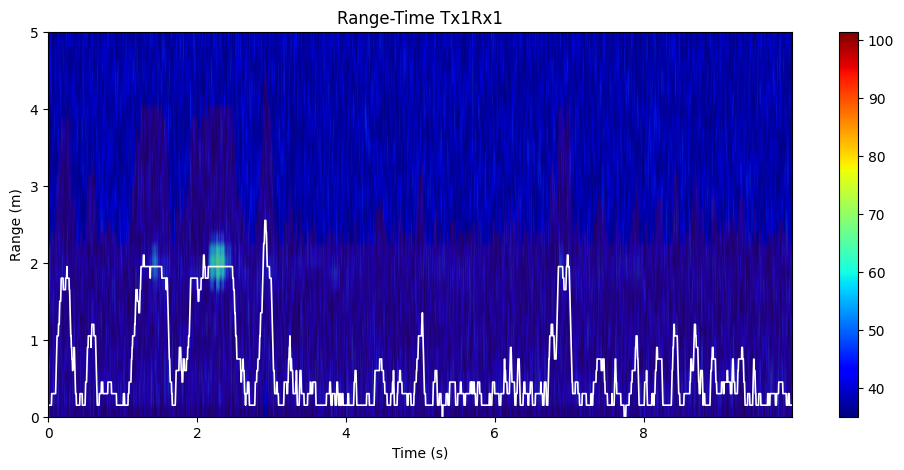

C:\Users\Kelly\AppData\Local\Temp\ipykernel_37036\2918788834.py:114: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Sxx = spectrogram(
C:\Users\Kelly\AppData\Local\Temp\ipykernel_37036\2918788834.py:149: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(np.abs(Data_spec_MTI2n)),


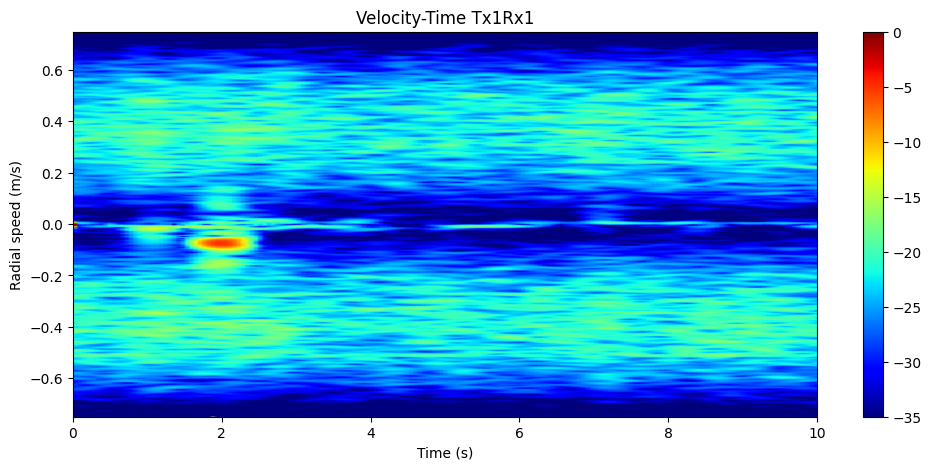

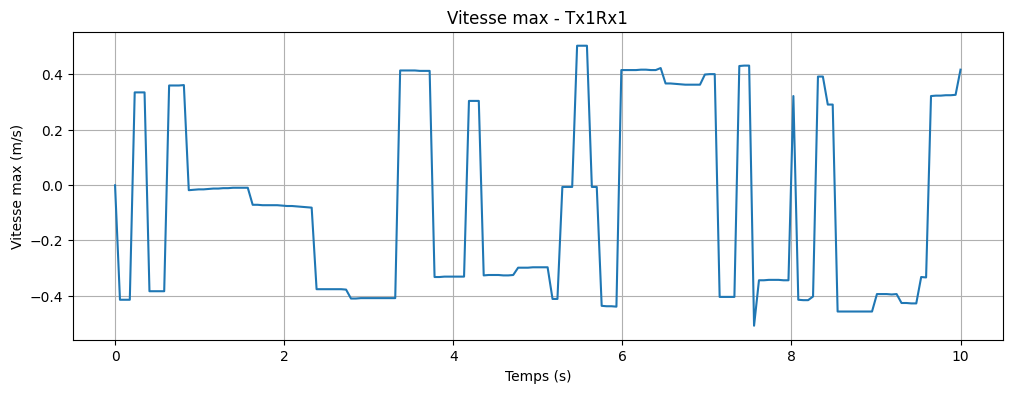

In [108]:
# ==========================================
# Affichage / traitement
# ==========================================
# Utilise la fonction show_one_rx_python définie précédemment
show_one_rx(Tx1, label, int(NTS), int(NumSweeps), fs, SweepTime, BandWidth, fc,
                   MIN_RANGE_FOR_DOPPLER_DETECTION, MAX_RANGE_FOR_DOPPLER_DETECTION, LANT)